In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", message=".*no associated frequency.*")

In [2]:
df = pd.read_excel("../merged_data.xlsx",) 

In [3]:
df.head()

,date,day,time,jay,dheeraj,shashi,total,dheeraj_hours,shashi_hours,tips: shashi,...,yash_hours,total_employees_hours,total_employees,nithin_hours,tips: yash,sunny,sunny_hours,siddharth,atharv,atharv_hours
0,2025-04-01,Tuesday,11 TO 8,306.0,NaN,NaN,306.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-04-02,Wednesday,11 TO 8,NaN,117.0,NaN,117.0,5.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-04-03,Thursday,11 TO 8,405.0,NaN,NaN,405.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-04-04,Friday,11 TO 9,NaN,650.0,NaN,650.0,5.5,9.0,2.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-04-05,Saturday,10 TO 9,NaN,615.0,NaN,615.0,10.0,6.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.shape

(1023, 26)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1023 entries, 0 to 1022
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   1005 non-null   datetime64[ns]
 1   day                    1006 non-null   object        
 2   time                   981 non-null    object        
 3   jay                    187 non-null    float64       
 4   dheeraj                257 non-null    float64       
 5   shashi                 170 non-null    float64       
 6   total                  1009 non-null   float64       
 7   dheeraj_hours          361 non-null    float64       
 8   shashi_hours           190 non-null    float64       
 9   tips: shashi           95 non-null     float64       
 10  tips: dheeraj          152 non-null    float64       
 11  source_file            1023 non-null   object        
 12  file_month             1023 non-null   int64         
 13  fil

In [6]:
df.drop(columns=['dheeraj','yash','jay','nithin','shashi','siddharth','atharv','sunny','file_month','file_year','source_file'], inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1023 entries, 0 to 1022
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   1005 non-null   datetime64[ns]
 1   day                    1006 non-null   object        
 2   time                   981 non-null    object        
 3   total                  1009 non-null   float64       
 4   dheeraj_hours          361 non-null    float64       
 5   shashi_hours           190 non-null    float64       
 6   tips: shashi           95 non-null     float64       
 7   tips: dheeraj          152 non-null    float64       
 8   yash_hours             301 non-null    float64       
 9   total_employees_hours  30 non-null     float64       
 10  total_employees        30 non-null     float64       
 11  nithin_hours           148 non-null    float64       
 12  tips: yash             41 non-null     float64       
 13  sun

In [8]:
df.dtypes

date                     datetime64[ns]
day                              object
time                             object
total                           float64
dheeraj_hours                   float64
shashi_hours                    float64
tips: shashi                    float64
tips: dheeraj                   float64
yash_hours                      float64
total_employees_hours           float64
total_employees                 float64
nithin_hours                    float64
tips: yash                      float64
sunny_hours                     float64
atharv_hours                    float64
dtype: object

In [9]:
column_types = {
    'date': 'datetime64[ns]',
    'day': 'string',
    'time': 'string',
    'total': 'float',
    'dheeraj_hours': 'float',
    'yash_hours': 'float',
    'total_employees_hours': 'float',
    'total_employees': 'Int64',  # Use nullable Int64
    'nithin_hours': 'float',
    'atharv_hours': 'float',
    'tips: yash': 'float',
    'tips: dheeraj': 'float',
    'shashi_hours': 'float',
    'tips: shashi': 'float',
    'sunny_hours': 'float',
}

for col, dtype in column_types.items():
    if col in df.columns:
        if dtype == 'datetime64[ns]':
            df[col] = pd.to_datetime(df[col], errors='coerce')
        else:
            df[col] = pd.to_numeric(df[col], errors='coerce') if 'float' in dtype or 'int' in dtype else df[col].astype(dtype)


In [10]:
df.dtypes

date                     datetime64[ns]
day                      string[python]
time                     string[python]
total                           float64
dheeraj_hours                   float64
shashi_hours                    float64
tips: shashi                    float64
tips: dheeraj                   float64
yash_hours                      float64
total_employees_hours           float64
total_employees                   Int64
nithin_hours                    float64
tips: yash                      float64
sunny_hours                     float64
atharv_hours                    float64
dtype: object

In [11]:
df.head()

,date,day,time,total,dheeraj_hours,shashi_hours,tips: shashi,tips: dheeraj,yash_hours,total_employees_hours,total_employees,nithin_hours,tips: yash,sunny_hours,atharv_hours
0,2025-04-01,Tuesday,11 TO 8,306.0,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
1,2025-04-02,Wednesday,11 TO 8,117.0,5.0,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
2,2025-04-03,Thursday,11 TO 8,405.0,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
3,2025-04-04,Friday,11 TO 9,650.0,5.5,9.0,2.5,13.64,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
4,2025-04-05,Saturday,10 TO 9,615.0,10.0,6.0,NaN,3.00,NaN,NaN,<NA>,NaN,NaN,NaN,NaN


In [12]:
df.columns

Index(['date', 'day', 'time', 'total', 'dheeraj_hours', 'shashi_hours',
       'tips: shashi', 'tips: dheeraj', 'yash_hours', 'total_employees_hours',
       'total_employees', 'nithin_hours', 'tips: yash', 'sunny_hours',
       'atharv_hours'],
      dtype='object')

In [13]:
import colorama.initialise
df.date.max()

Timestamp('2026-02-28 00:00:00')

In [14]:
# Count rows where every column is null
empty_rows_count = df.isna().all(axis=1).sum()

empty_rows_count

5

In [15]:
empty_rows = df[df.isna().all(axis=1)]
empty_rows

,date,day,time,total,dheeraj_hours,shashi_hours,tips: shashi,tips: dheeraj,yash_hours,total_employees_hours,total_employees,nithin_hours,tips: yash,sunny_hours,atharv_hours
30,NaT,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
339,NaT,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
340,NaT,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
649,NaT,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
776,NaT,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN


In [16]:
# df= df[~df[df.isna().all(axis=1)]] can be used but it is not efficient
df = df.dropna(how="all")

In [17]:
df.isna().all(axis=1).sum()

0

In [18]:
df.dtypes

date                     datetime64[ns]
day                      string[python]
time                     string[python]
total                           float64
dheeraj_hours                   float64
shashi_hours                    float64
tips: shashi                    float64
tips: dheeraj                   float64
yash_hours                      float64
total_employees_hours           float64
total_employees                   Int64
nithin_hours                    float64
tips: yash                      float64
sunny_hours                     float64
atharv_hours                    float64
dtype: object

In [19]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [20]:
invalid_dates_mask = df['date'].isna()
# View the original rows that had invalid dates
# (Assuming you want to see what the data looked like before you overwrote the column, 
# you might want to do the check on a copy or check the original file if overwritten)
invalid_rows = df[invalid_dates_mask]
# Count how many invalid dates there are
print(f"Number of invalid dates: {invalid_dates_mask.sum()}")
# Display the rows
display(invalid_rows)

Number of invalid dates: 13


,date,day,time,total,dheeraj_hours,shashi_hours,tips: shashi,tips: dheeraj,yash_hours,total_employees_hours,total_employees,nithin_hours,tips: yash,sunny_hours,atharv_hours
31,NaT,<NA>,<NA>,0.0,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
123,NaT,<NA>,<NA>,0.0,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
341,NaT,340,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
370,NaT,<NA>,<NA>,0.0,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
371,NaT,<NA>,<NA>,0.0,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
372,NaT,<NA>,<NA>,0.0,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
463,NaT,<NA>,<NA>,NaN,NaN,NaN,NaN,6.4,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
588,NaT,<NA>,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
650,NaT,<NA>,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
682,NaT,<NA>,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN


In [21]:

df = df.dropna(subset=['date'])

In [22]:
df['day']=df['date'].dt.day_name()

In [23]:

df.day.unique()

array(['Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday',
       'Monday'], dtype=object)

In [24]:
print(df['day'].unique())

['Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday' 'Sunday' 'Monday']


In [25]:
#null count summary

def null_report (df):
    null_summary = df.isnull().sum().to_frame(name='Null Count')
    null_summary['% Missing'] = (null_summary['Null Count'] / len(df) * 100).round(2)
    null_summary = null_summary[null_summary['Null Count'] > 0]  # Optional: show only columns with missing values
    print(null_summary)

In [26]:
null_report(df)


                       Null Count  % Missing
time                           28       2.79
total                           4       0.40
dheeraj_hours                 644      64.08
shashi_hours                  815      81.09
tips: shashi                  910      90.55
tips: dheeraj                 854      84.98
yash_hours                    704      70.05
total_employees_hours         975      97.01
total_employees               975      97.01
nithin_hours                  857      85.27
tips: yash                    964      95.92
sunny_hours                   982      97.71
atharv_hours                 1002      99.70


In [27]:
def get_time(date):
    if date.month == 12:
        if date.strftime("%m/%d") == "12/24":
            return "9 to 6"
        elif date.strftime("%m/%d") == "12/25":
            return "Closed"
        elif date.strftime("%m/%d") == "12/31":
            return "11 to 6"
        elif date.weekday() == 6:  # Sunday
            return "11 to 7"
        else:
            return "10 to 9"
    else:
        weekday_schedule = {
            0: "10 to 9",  # Monday
            1: "11 to 8",  # Tuesday
            2: "11 to 8",  # Wednesday
            3: "11 to 8",  # Thursday
            4: "11 to 9",  # Friday
            5: "10 to 9",  # Saturday
            6: "11 to 7"   # Sunday
        }
        return weekday_schedule[date.weekday()]

In [28]:
df['time'] = df['date'].apply(get_time)

In [29]:
columns_to_fill = ['dheeraj_hours', 'yash_hours','total_employees_hours', 'total_employees','nithin_hours','atharv_hours','tips: yash','tips: dheeraj','shashi_hours','tips: shashi','sunny_hours']  # replace with your actual column names

# Fill missing values with 0
df.loc[:, columns_to_fill] = df.loc[:, columns_to_fill].fillna(0)


In [30]:
df= df[~df.total.isna()]

In [31]:
df['date'].max()

Timestamp('2026-02-28 00:00:00')

In [32]:
null_report(df)


Empty DataFrame
Columns: [Null Count, % Missing]
Index: []


In [33]:
df.columns

Index(['date', 'day', 'time', 'total', 'dheeraj_hours', 'shashi_hours',
       'tips: shashi', 'tips: dheeraj', 'yash_hours', 'total_employees_hours',
       'total_employees', 'nithin_hours', 'tips: yash', 'sunny_hours',
       'atharv_hours'],
      dtype='object')

In [34]:
df.dtypes

date                     datetime64[ns]
day                              object
time                             object
total                           float64
dheeraj_hours                   float64
shashi_hours                    float64
tips: shashi                    float64
tips: dheeraj                   float64
yash_hours                      float64
total_employees_hours           float64
total_employees                   Int64
nithin_hours                    float64
tips: yash                      float64
sunny_hours                     float64
atharv_hours                    float64
dtype: object

In [35]:
df.loc[:, 'total_employees_hours'] = df[
    ['dheeraj_hours', 'yash_hours', 'nithin_hours', 'shashi_hours', 'atharv_hours', 'sunny_hours']
].sum(axis=1)


In [36]:
df.head()

,date,day,time,total,dheeraj_hours,shashi_hours,tips: shashi,tips: dheeraj,yash_hours,total_employees_hours,total_employees,nithin_hours,tips: yash,sunny_hours,atharv_hours
0,2025-04-01,Tuesday,11 to 8,306.0,0.0,0.0,0.0,0.00,0.0,0.0,0,0.0,0.0,0.0,0.0
1,2025-04-02,Wednesday,11 to 8,117.0,5.0,0.0,0.0,0.00,0.0,5.0,0,0.0,0.0,0.0,0.0
2,2025-04-03,Thursday,11 to 8,405.0,0.0,0.0,0.0,0.00,0.0,0.0,0,0.0,0.0,0.0,0.0
3,2025-04-04,Friday,11 to 9,650.0,5.5,9.0,2.5,13.64,0.0,14.5,0,0.0,0.0,0.0,0.0
4,2025-04-05,Saturday,10 to 9,615.0,10.0,6.0,0.0,3.00,0.0,16.0,0,0.0,0.0,0.0,0.0


In [37]:
df.head()

,date,day,time,total,dheeraj_hours,shashi_hours,tips: shashi,tips: dheeraj,yash_hours,total_employees_hours,total_employees,nithin_hours,tips: yash,sunny_hours,atharv_hours
0,2025-04-01,Tuesday,11 to 8,306.0,0.0,0.0,0.0,0.00,0.0,0.0,0,0.0,0.0,0.0,0.0
1,2025-04-02,Wednesday,11 to 8,117.0,5.0,0.0,0.0,0.00,0.0,5.0,0,0.0,0.0,0.0,0.0
2,2025-04-03,Thursday,11 to 8,405.0,0.0,0.0,0.0,0.00,0.0,0.0,0,0.0,0.0,0.0,0.0
3,2025-04-04,Friday,11 to 9,650.0,5.5,9.0,2.5,13.64,0.0,14.5,0,0.0,0.0,0.0,0.0
4,2025-04-05,Saturday,10 to 9,615.0,10.0,6.0,0.0,3.00,0.0,16.0,0,0.0,0.0,0.0,0.0


In [38]:
df.loc[:, 'total_tips'] = df[['tips: yash','tips: dheeraj','tips: shashi']].sum(axis=1)

In [39]:
df.head()

,date,day,time,total,dheeraj_hours,shashi_hours,tips: shashi,tips: dheeraj,yash_hours,total_employees_hours,total_employees,nithin_hours,tips: yash,sunny_hours,atharv_hours,total_tips
0,2025-04-01,Tuesday,11 to 8,306.0,0.0,0.0,0.0,0.00,0.0,0.0,0,0.0,0.0,0.0,0.0,0.00
1,2025-04-02,Wednesday,11 to 8,117.0,5.0,0.0,0.0,0.00,0.0,5.0,0,0.0,0.0,0.0,0.0,0.00
2,2025-04-03,Thursday,11 to 8,405.0,0.0,0.0,0.0,0.00,0.0,0.0,0,0.0,0.0,0.0,0.0,0.00
3,2025-04-04,Friday,11 to 9,650.0,5.5,9.0,2.5,13.64,0.0,14.5,0,0.0,0.0,0.0,0.0,16.14
4,2025-04-05,Saturday,10 to 9,615.0,10.0,6.0,0.0,3.00,0.0,16.0,0,0.0,0.0,0.0,0.0,3.00


In [40]:
df2 = df.drop(columns=['dheeraj_hours', 'yash_hours', 'nithin_hours','shashi_hours', 'atharv_hours', 'sunny_hours','tips: yash', 'tips: dheeraj', 'tips: shashi'])

In [41]:
df2.head()

,date,day,time,total,total_employees_hours,total_employees,total_tips
0,2025-04-01,Tuesday,11 to 8,306.0,0.0,0,0.00
1,2025-04-02,Wednesday,11 to 8,117.0,5.0,0,0.00
2,2025-04-03,Thursday,11 to 8,405.0,0.0,0,0.00
3,2025-04-04,Friday,11 to 9,650.0,14.5,0,16.14
4,2025-04-05,Saturday,10 to 9,615.0,16.0,0,3.00


In [42]:
null_report(df2)

Empty DataFrame
Columns: [Null Count, % Missing]
Index: []


In [43]:
df2[df2.total.isna()]

,date,day,time,total,total_employees_hours,total_employees,total_tips


In [44]:
df2[df2.total.isna()]

,date,day,time,total,total_employees_hours,total_employees,total_tips


In [45]:
df2[df2.isnull()]

,date,day,time,total,total_employees_hours,total_employees,total_tips
0,NaT,NaN,NaN,NaN,NaN,<NA>,NaN
1,NaT,NaN,NaN,NaN,NaN,<NA>,NaN
2,NaT,NaN,NaN,NaN,NaN,<NA>,NaN
3,NaT,NaN,NaN,NaN,NaN,<NA>,NaN
4,NaT,NaN,NaN,NaN,NaN,<NA>,NaN
...,...,...,...,...,...,...,...
1017,NaT,NaN,NaN,NaN,NaN,<NA>,NaN
1018,NaT,NaN,NaN,NaN,NaN,<NA>,NaN
1019,NaT,NaN,NaN,NaN,NaN,<NA>,NaN
1020,NaT,NaN,NaN,NaN,NaN,<NA>,NaN


In [46]:

df2.isnull().sum()


date                     0
day                      0
time                     0
total                    0
total_employees_hours    0
total_employees          0
total_tips               0
dtype: int64

In [47]:
df2.dropna(subset=['total'], inplace=True)
df2.isnull().sum()

date                     0
day                      0
time                     0
total                    0
total_employees_hours    0
total_employees          0
total_tips               0
dtype: int64

In [48]:
# IMPORTANT: Don't forward-fill the target (`total`) before evaluation (data leakage).
# Since only a few rows have missing totals, we drop them instead.
df2 = df2.sort_values('date').reset_index(drop=True)
df2 = df2.dropna(subset=['total']).copy()

In [49]:
df2.isnull().sum()

date                     0
day                      0
time                     0
total                    0
total_employees_hours    0
total_employees          0
total_tips               0
dtype: int64

In [50]:
df2.total_tips.describe()

count    1001.000000
mean        2.625974
std         6.227856
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max        63.400000
Name: total_tips, dtype: float64

In [51]:
df2.total.describe()

count    1001.000000
mean      401.823806
std       315.268775
min         0.000000
25%       202.000000
50%       333.000000
75%       509.000000
max      2822.000000
Name: total, dtype: float64

In [52]:
df2.head()

,date,day,time,total,total_employees_hours,total_employees,total_tips
0,2022-11-01,Tuesday,11 to 8,147.0,8.5,0,0.0
1,2022-11-02,Wednesday,11 to 8,81.0,0.0,0,0.0
2,2022-11-03,Thursday,11 to 8,18.0,0.0,0,0.0
3,2022-11-04,Friday,11 to 9,27.0,9.0,0,0.0
4,2022-11-05,Saturday,10 to 9,260.0,10.0,0,0.0


In [53]:
df2.total_employees_hours.describe()

count    1001.000000
mean        8.273127
std         5.363274
min         0.000000
25%         5.500000
50%         8.500000
75%        10.000000
max        33.000000
Name: total_employees_hours, dtype: float64

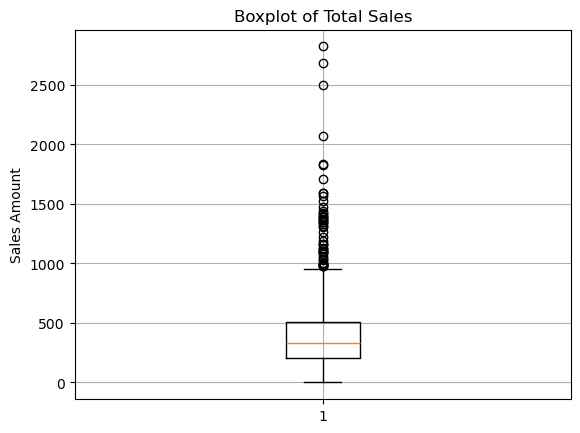

In [54]:
plt.boxplot(df2['total'].dropna())  # dropna() to avoid errors from NaNs
plt.title("Boxplot of Total Sales")
plt.ylabel("Sales Amount")
plt.grid(True)
plt.show()

In [55]:
quarterly_sales = df2.groupby(df2['date'].dt.to_period('Q'))['total'].sum().reset_index()

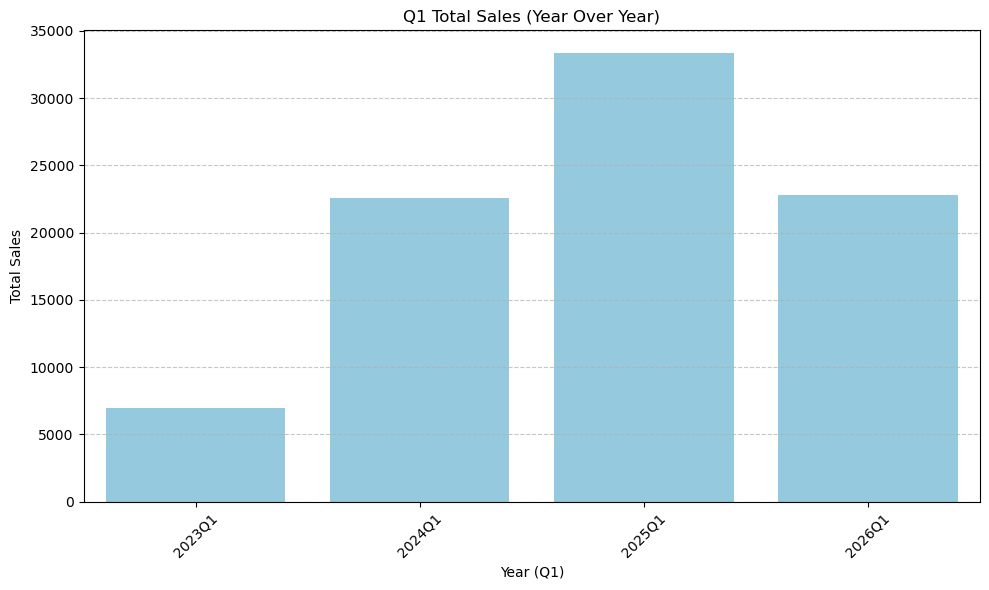

In [56]:
q1_sales = quarterly_sales[quarterly_sales['date'].dt.quarter == 1]
# 2. Plot the Bar Graph
plt.figure(figsize=(10, 6))
# We convert 'date' to a string just for plotting so the x-axis labels look clean
sns.barplot(data=q1_sales, x=q1_sales['date'].astype(str), y='total', color='skyblue')
plt.title('Q1 Total Sales (Year Over Year)')
plt.xlabel('Year (Q1)')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

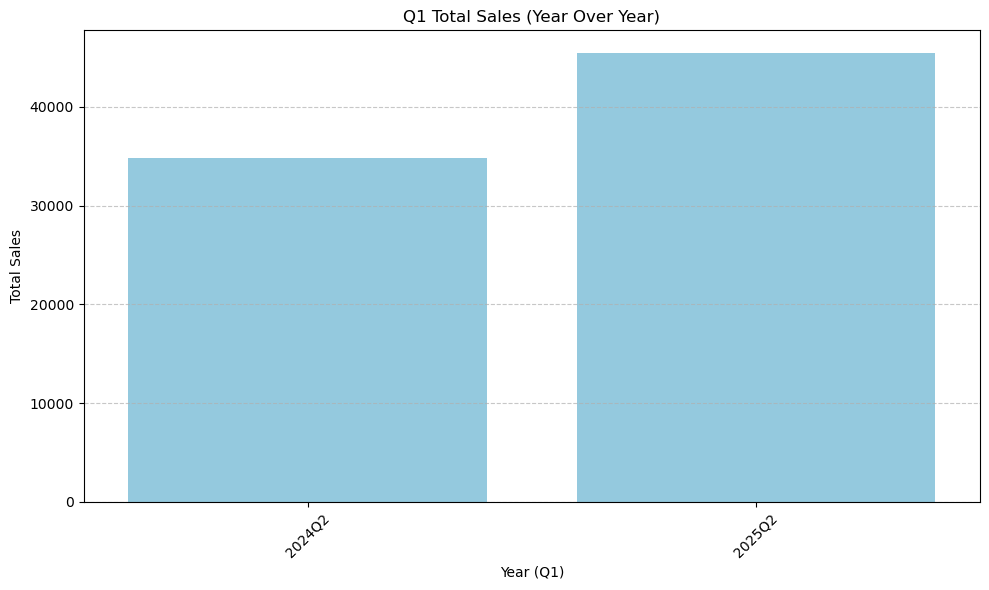

In [57]:
q2_sales = quarterly_sales[quarterly_sales['date'].dt.quarter == 2]
# 2. Plot the Bar Graph
plt.figure(figsize=(10, 6))
# We convert 'date' to a string just for plotting so the x-axis labels look clean
sns.barplot(data=q2_sales, x=q2_sales['date'].astype(str), y='total', color='skyblue')
plt.title('Q1 Total Sales (Year Over Year)')
plt.xlabel('Year (Q1)')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [58]:
df2.groupby(df2.date.dt.year).sum(numeric_only=True)

,total,total_employees_hours,total_employees,total_tips
date,,,,
2022,19484.00,510.5,0,0.00
2023,46405.00,1901.2,0,0.00
2024,144615.63,2734.7,35,1002.44
2025,168947.00,2707.5,0,1392.59
2026,22774.00,427.5,0,233.57


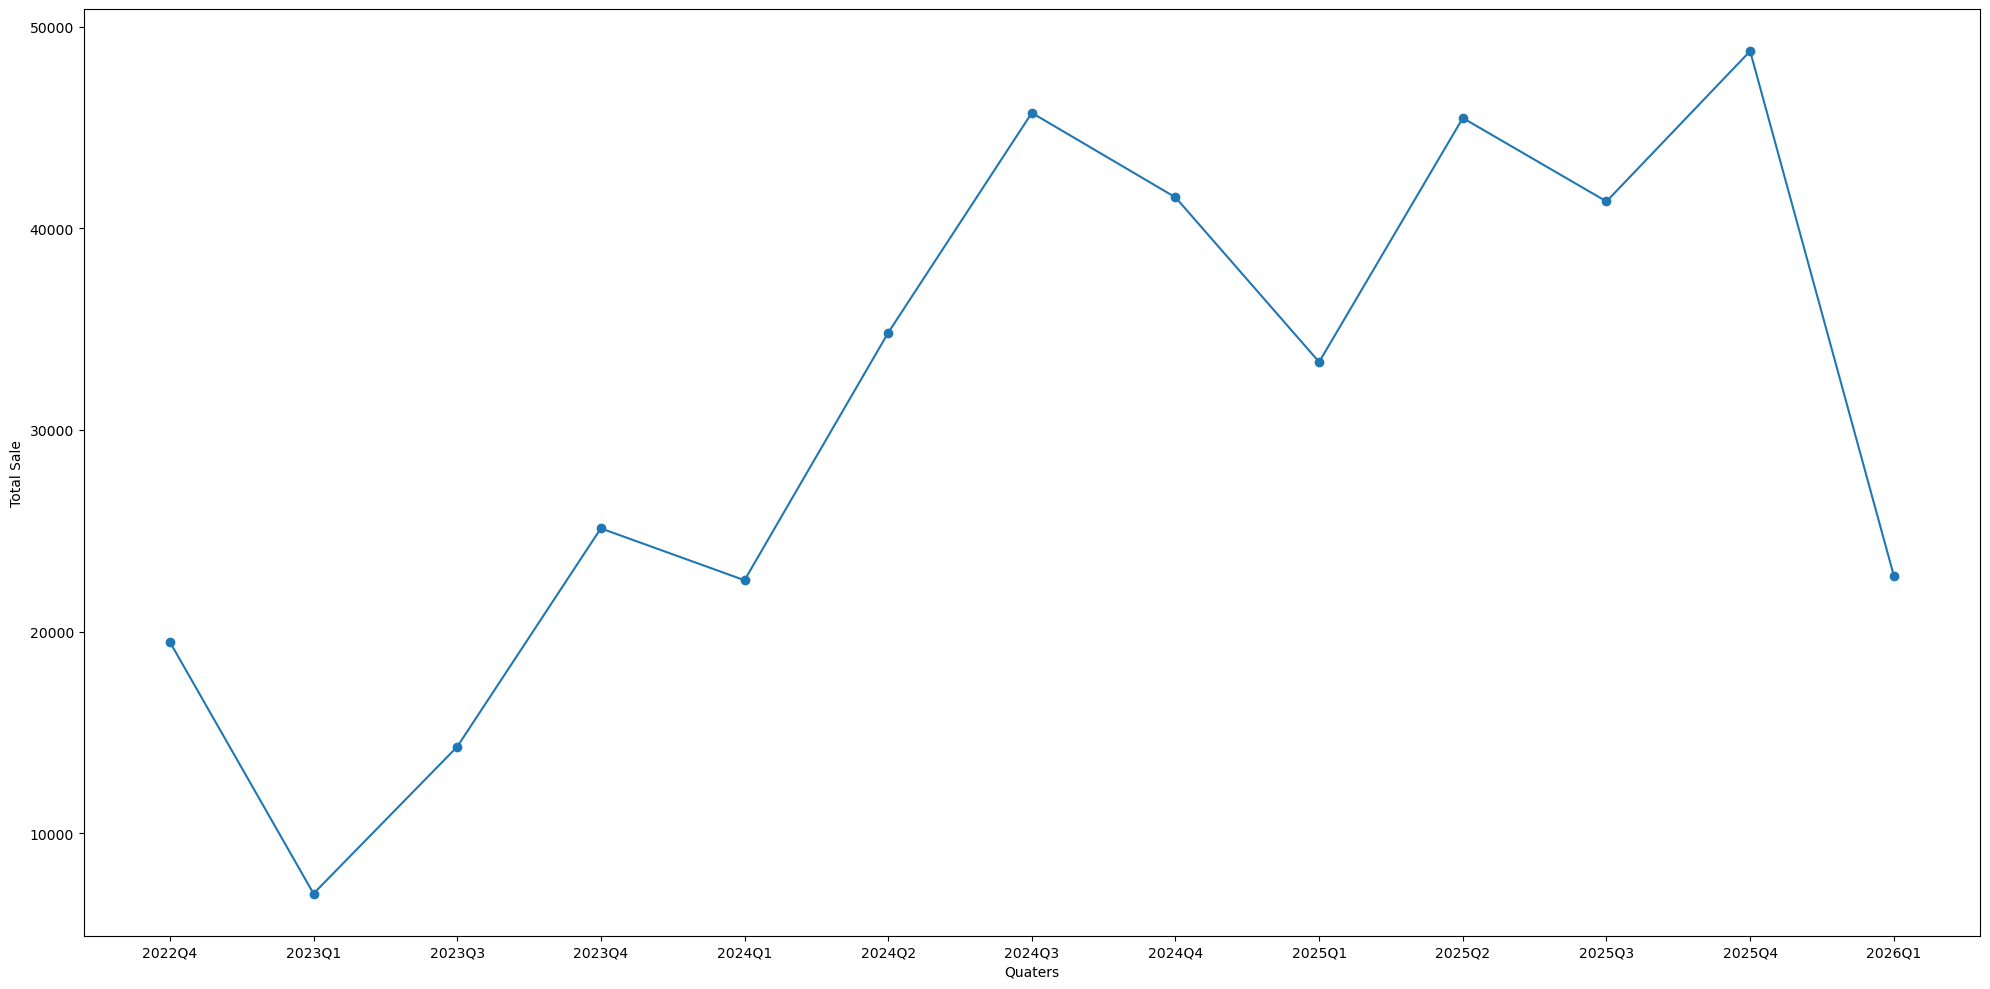

In [59]:
# plt.bar(quarterly_sales,x='Quarters',y='total sales')\
from matplotlib import markers


plt.figure(figsize=(20,10))
plt.plot(quarterly_sales['date'].astype(str), quarterly_sales['total'],marker='o')
plt.xlabel('Quaters')
plt.ylabel('Total Sale')
plt.tight_layout()
plt.show()

<Axes: >

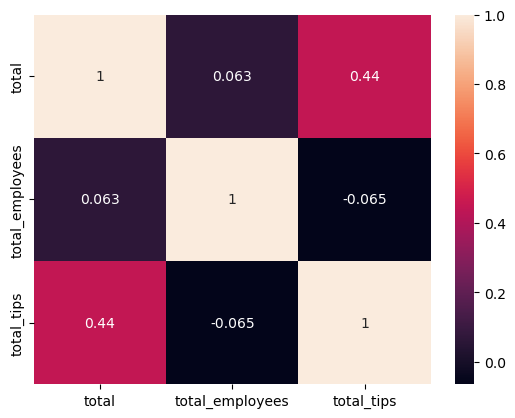

In [60]:
corelation_matrix=df2[['total','total_employees','total_tips']].corr()
sns.heatmap(corelation_matrix,annot=True)


In [61]:
df2.head()

,date,day,time,total,total_employees_hours,total_employees,total_tips
0,2022-11-01,Tuesday,11 to 8,147.0,8.5,0,0.0
1,2022-11-02,Wednesday,11 to 8,81.0,0.0,0,0.0
2,2022-11-03,Thursday,11 to 8,18.0,0.0,0,0.0
3,2022-11-04,Friday,11 to 9,27.0,9.0,0,0.0
4,2022-11-05,Saturday,10 to 9,260.0,10.0,0,0.0


In [62]:
df2.columns

Index(['date', 'day', 'time', 'total', 'total_employees_hours',
       'total_employees', 'total_tips'],
      dtype='object')

In [63]:
df['date'].max()

Timestamp('2026-02-28 00:00:00')

In [64]:
df2['month'] = df2['date'].dt.month

df2['week'] = df2['date'].dt.isocalendar().week

In [65]:
df2.head(15)

,date,day,time,total,total_employees_hours,total_employees,total_tips,month,week
0,2022-11-01,Tuesday,11 to 8,147.0,8.5,0,0.0,11,44
1,2022-11-02,Wednesday,11 to 8,81.0,0.0,0,0.0,11,44
2,2022-11-03,Thursday,11 to 8,18.0,0.0,0,0.0,11,44
3,2022-11-04,Friday,11 to 9,27.0,9.0,0,0.0,11,44
4,2022-11-05,Saturday,10 to 9,260.0,10.0,0,0.0,11,44
5,2022-11-06,Sunday,11 to 7,81.0,10.0,0,0.0,11,44
6,2022-11-07,Monday,10 to 9,306.0,9.0,0,0.0,11,45
7,2022-11-08,Tuesday,11 to 8,123.0,0.0,0,0.0,11,45
8,2022-11-09,Wednesday,11 to 8,90.0,0.0,0,0.0,11,45
9,2022-11-10,Thursday,11 to 8,108.0,0.0,0,0.0,11,45


In [66]:
df2['year'] = df2['date'].dt.year
df2['quarter'] = df2['date'].dt.quarter
df2['is_weekend'] = df2['day'].isin(['Saturday','Sunday']).astype(bool)

In [67]:
yearly_sale = df2.groupby(by= 'year').total.sum().reset_index()

In [68]:
print(yearly_sale)

   year      total
0  2022   19484.00
1  2023   46405.00
2  2024  144615.63
3  2025  168947.00
4  2026   22774.00


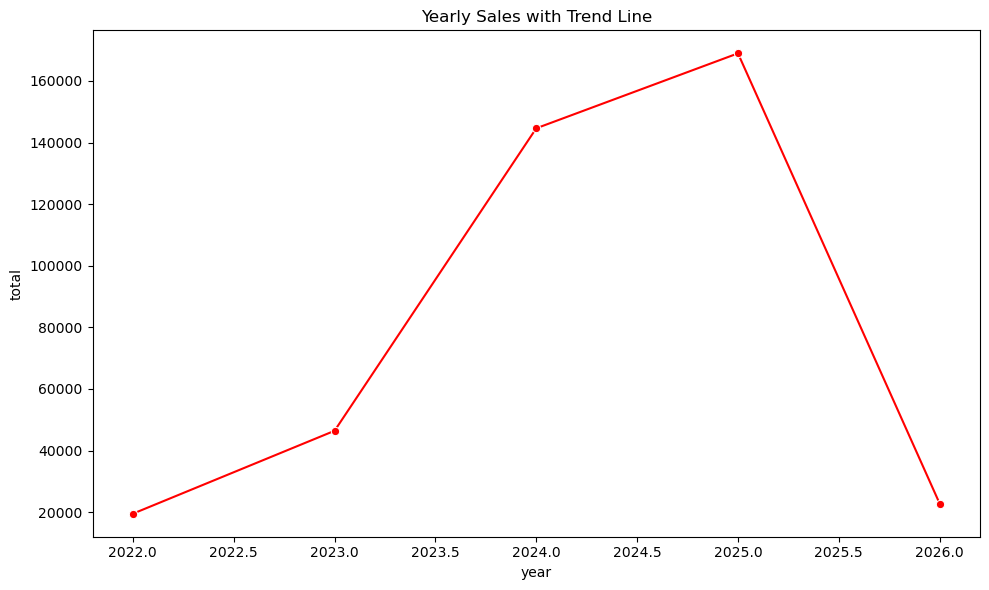

In [69]:
plt.figure(figsize=(10, 6))
# sns.barplot(data=yearly_sale, x='year', y='total', color='skyblue')
sns.lineplot(data=yearly_sale, x='year', y='total', color='red', marker='o')
plt.title("Yearly Sales with Trend Line")
plt.tight_layout()
plt.show()


In [70]:
df2.dtypes

date                     datetime64[ns]
day                              object
time                             object
total                           float64
total_employees_hours           float64
total_employees                   Int64
total_tips                      float64
month                             int32
week                             UInt32
year                              int32
quarter                           int32
is_weekend                         bool
dtype: object

In [71]:
from pandas.api.types import CategoricalDtype

day_wise_sales = df2.groupby(by='day')[['total','total_tips']].sum().reset_index()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
cat_dtype = CategoricalDtype(categories=days_order, ordered=True)
day_wise_sales['day'] = day_wise_sales['day'].astype(cat_dtype)
day_wise_sales = day_wise_sales.sort_values('day')
melted = day_wise_sales.melt(id_vars='day', value_vars=['total', 'total_tips'],
                             var_name='Metric', value_name='Amount')
print(melted)

          day      Metric    Amount
0      Monday       total  47908.00
1     Tuesday       total  53537.63
2   Wednesday       total  50837.00
3    Thursday       total  49006.00
4      Friday       total  66075.00
5    Saturday       total  81363.00
6      Sunday       total  53499.00
7      Monday  total_tips    362.48
8     Tuesday  total_tips    310.11
9   Wednesday  total_tips    266.87
10   Thursday  total_tips    253.08
11     Friday  total_tips    349.39
12   Saturday  total_tips    537.00
13     Sunday  total_tips    549.67


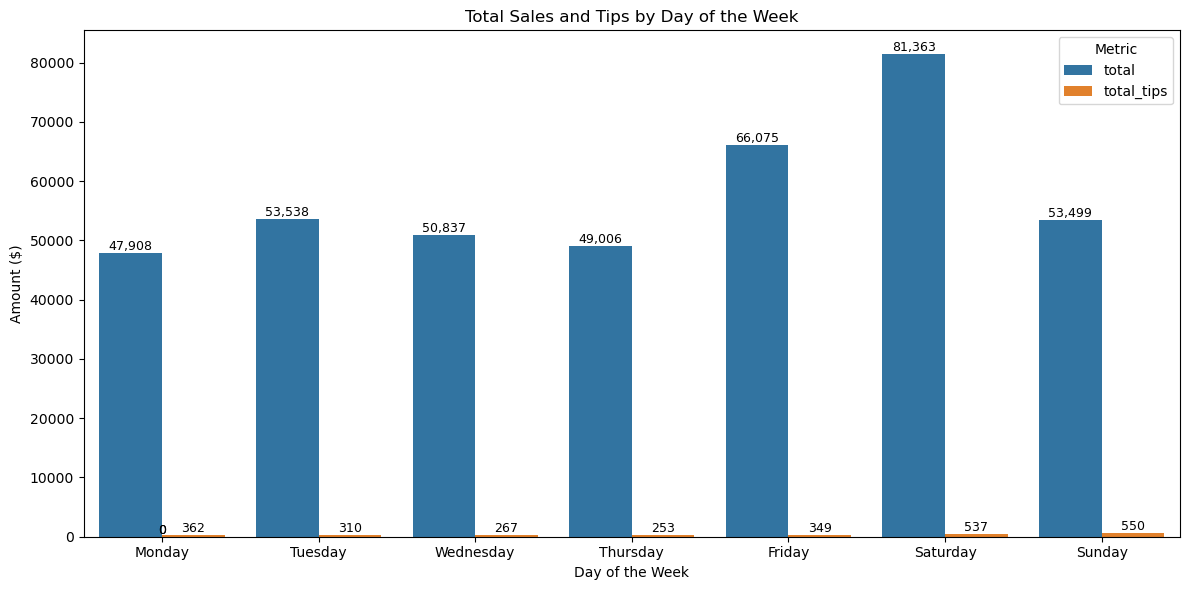

In [72]:
# Step 4: Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=melted, x='day', y='Amount', hue='Metric')

# Step 5: Add value labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):  # skip NaNs
        ax.text(
            x=p.get_x() + p.get_width() / 2,
            y=height,
            s=f'{height:,.0f}',  # format number
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.title("Total Sales and Tips by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Amount ($)")
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

# Calculating Moving Average

In [73]:
# # Ensure date is index
df2 = df2.sort_values("date")
df2.set_index("date", inplace=True)


In [74]:
df2['total:10_days_rolling'] = df2['total'].shift(1).rolling(window=10).mean()
df2['total:30_days_rolling'] = df2['total'].shift(1).rolling(window=30).mean()
df2['total:50_days_rolling'] = df2['total'].shift(1).rolling(window=50).mean()

In [75]:
df2.index.max()

Timestamp('2026-02-28 00:00:00')

<Axes: xlabel='date'>

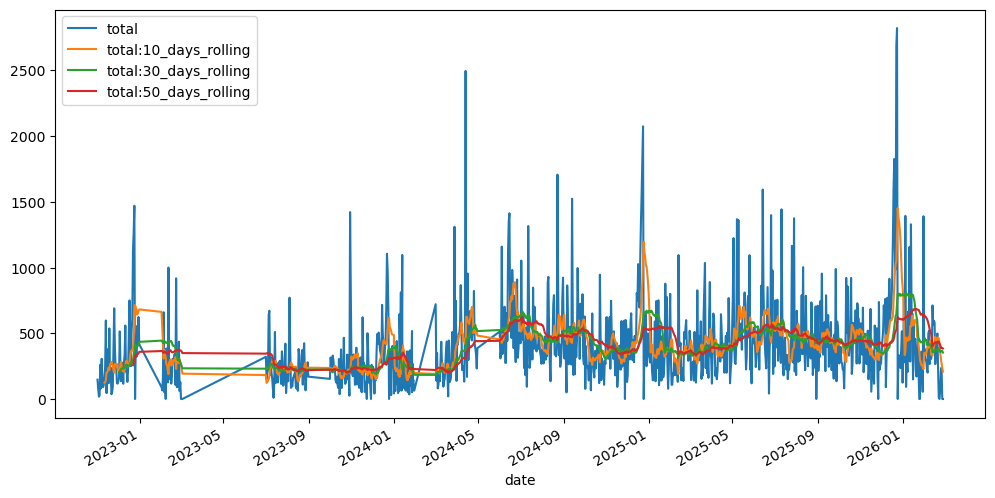

In [76]:
df2[['total','total:10_days_rolling','total:30_days_rolling','total:50_days_rolling']].plot(figsize=(12,6))

<Axes: xlabel='date'>

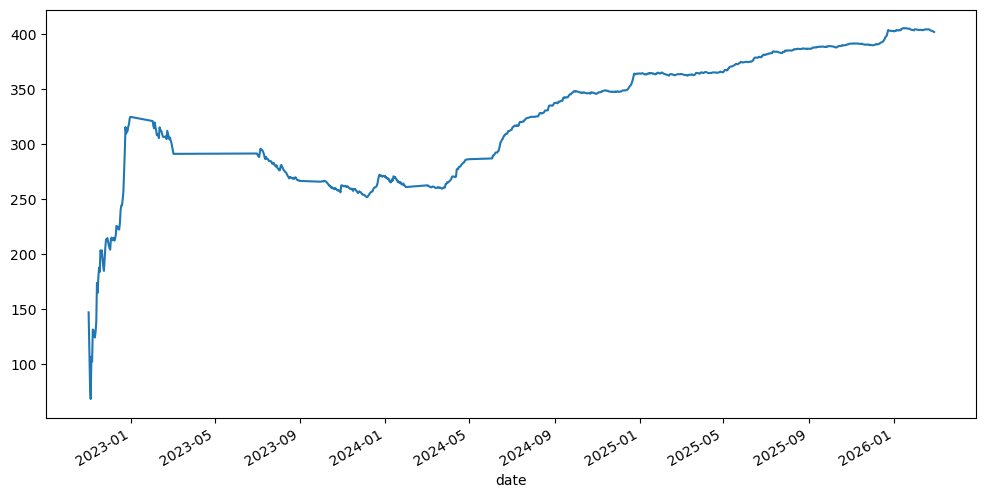

In [77]:
# Cumulative Moving Average 
df2['total'].expanding().mean().plot(figsize=(12,6))

In [78]:
df2.index.max()

Timestamp('2026-02-28 00:00:00')

# Classical Time Series Decomposition

In [79]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition_additive = seasonal_decompose(df2['total'], model='additive', period= 7)# Model Building

In [80]:
trend_additive = decomposition_additive.trend
seasonal_additive = decomposition_additive.seasonal
residual_additive = decomposition_additive.resid

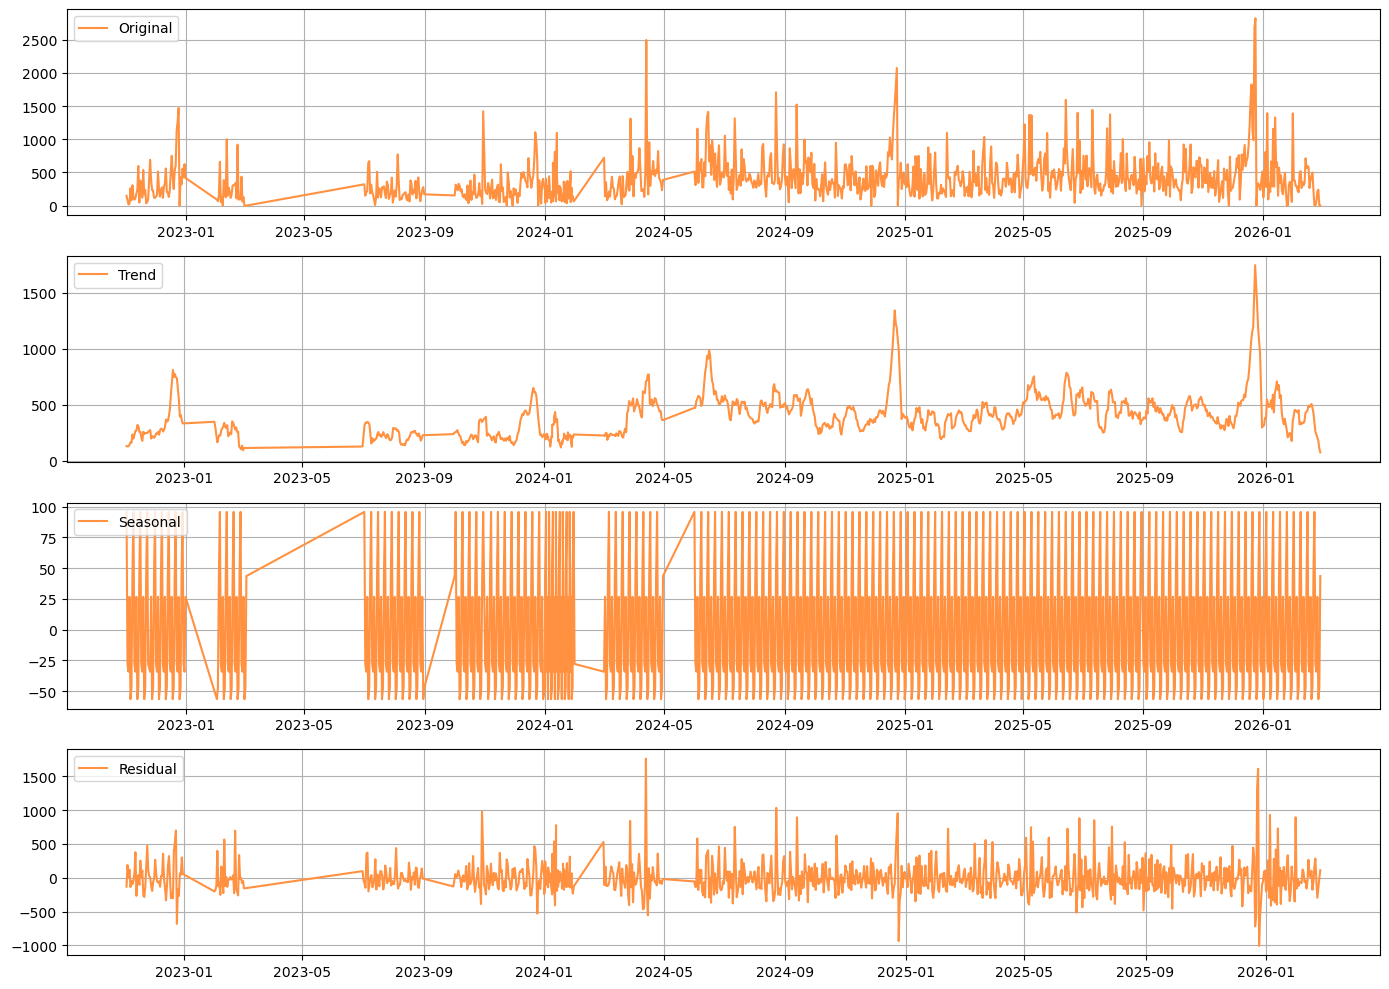

In [81]:
plt.figure(figsize= (14,10))
plt.subplot(411)
plt.plot(df2['total'], label = 'Original', color = '#FF9140')
plt.grid(True)
plt.legend(loc= 'upper left')
plt.subplot(412)
plt.grid(True)
plt.plot(trend_additive, label = 'Trend', color = '#FF9140')
plt.legend(loc= 'upper left')
plt.subplot(413)
plt.grid(True)
plt.plot(seasonal_additive, label = 'Seasonal', color = '#FF9140')
plt.legend(loc= 'upper left')
plt.subplot(414)
plt.grid(True)
plt.plot(residual_additive, label = 'Residual', color = '#FF9140')
plt.legend(loc= 'upper left')
plt.tight_layout()
plt.show()



In [82]:
df2.is_weekend = df2.is_weekend.astype('int')

In [83]:
df2[df2['total']==0]

,day,time,total,total_employees_hours,total_employees,total_tips,month,week,year,quarter,is_weekend,total:10_days_rolling,total:30_days_rolling,total:50_days_rolling
date,,,,,,,,,,,,,,
2022-12-25,Sunday,Closed,0.0,0.0,0,0.0,12,51,2022,4,1,715.7,415.666667,329.44
2023-02-07,Tuesday,11 to 8,0.0,7.5,0,0.0,2,6,2023,1,0,317.5,430.100000,352.68
2023-03-01,Wednesday,11 to 8,0.0,0.0,0,0.0,3,9,2023,1,0,257.9,268.166667,367.16
2023-03-02,Thursday,11 to 8,0.0,0.0,0,0.0,3,9,2023,1,0,227.1,247.366667,360.46
2023-03-03,Friday,11 to 9,0.0,0.0,0,0.0,3,9,2023,1,0,192.9,233.466667,349.28
2023-11-23,Thursday,11 to 8,0.0,0.0,0,0.0,11,47,2023,4,0,207.5,238.633333,227.28
2023-11-29,Wednesday,11 to 8,0.0,7.5,0,0.0,11,48,2023,4,0,183.1,243.966667,221.20
2023-12-25,Monday,Closed,0.0,0.0,0,0.0,12,52,2023,4,0,617.3,379.500000,310.34
2024-11-28,Thursday,11 to 8,0.0,0.0,0,0.0,11,48,2024,4,0,336.0,373.200000,358.74


In [84]:
df2['is_future'] = df2.index > '2026-02-28'

df2['is_closed'] = (
    (df2['total'] == 0) &
    (df2['total_employees_hours'] == 0) &
    (df2['total_employees'] == 0)
)

df2['is_suspicious_zero'] = (
    (df2['total'] == 0) &
    (df2['total_employees_hours'] > 0)
)


In [85]:
# Drop future data

df2 = df2[~df2['is_future']]

# Drop suspicious zeros
df2 = df2[~df2['is_suspicious_zero']]

df2['store_open'] = (~df2['is_closed']).astype(int)


In [86]:
df2.head()

,day,time,total,total_employees_hours,total_employees,total_tips,month,week,year,quarter,is_weekend,total:10_days_rolling,total:30_days_rolling,total:50_days_rolling,is_future,is_closed,is_suspicious_zero,store_open
date,,,,,,,,,,,,,,,,,,
2022-11-01,Tuesday,11 to 8,147.0,8.5,0,0.0,11,44,2022,4,0,NaN,NaN,NaN,False,False,False,1
2022-11-02,Wednesday,11 to 8,81.0,0.0,0,0.0,11,44,2022,4,0,NaN,NaN,NaN,False,False,False,1
2022-11-03,Thursday,11 to 8,18.0,0.0,0,0.0,11,44,2022,4,0,NaN,NaN,NaN,False,False,False,1
2022-11-04,Friday,11 to 9,27.0,9.0,0,0.0,11,44,2022,4,0,NaN,NaN,NaN,False,False,False,1
2022-11-05,Saturday,10 to 9,260.0,10.0,0,0.0,11,44,2022,4,1,NaN,NaN,NaN,False,False,False,1


## Stationarity Tests:

### 1. ADF Test

In [87]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, alpha=0.05, name="Time Series"):
    """
    Perform Augmented Dickey-Fuller test and print results.

    Parameters:
        series : pandas Series
            Time series data to test
        alpha : float
            Significance level (default 0.05)
        name : str
            Name of the series (for display)
    """
    result = adfuller(series.dropna())

    print(f"\nADF Test Results for {name}")
    print("-" * 40)
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"  {key}: {value:.4f}")

    if result[1] <= alpha:
        print(f"Result: Stationary (reject H₀ at α={alpha})")
    else:
        print(f"Result: Non-stationary (fail to reject H₀ at α={alpha})")


In [88]:
df2.index.max()

Timestamp('2026-02-28 00:00:00')

In [89]:
adf_test(df2['total'], name="Daily Sales")


ADF Test Results for Daily Sales
----------------------------------------
ADF Statistic: -6.9972
p-value: 0.0000
Critical Values:
  1%: -3.4370
  5%: -2.8645
  10%: -2.5683
Result: Stationary (reject H₀ at α=0.05)


### 2. KPSS Test



In [90]:
from statsmodels.tsa.stattools import kpss

def kpss_test(series, regression='ct', alpha=0.05, name="Time Series"):
    """
    Perform KPSS test and print results.

    Parameters:
        series : pandas Series
            Time series data to test
        regression : str
            'c'  = constant (level stationarity)
            'ct' = constant + trend (trend stationarity)
            'n'  = no constant, no trend
        alpha : float
            Significance level (default 0.05)
        name : str
            Name of the series (for display)
    """
    statistic, p_value, lags, critical_values = kpss(series.dropna(), regression=regression)

    print(f"\nKPSS Test Results for {name}")
    print("-" * 40)
    print(f"KPSS Statistic: {statistic:.4f}")
    print(f"p-value: {p_value:.4f}")
    print("Critical Values:")
    for key, value in critical_values.items():
        print(f"  {key}: {value:.4f}")

    if p_value <= alpha:
        print(f"Result: NON-stationary (reject H₀ at α={alpha})")
    else:
        print(f"Result: Stationary (fail to reject H₀ at α={alpha})")


In [91]:
df2.index.max()

Timestamp('2026-02-28 00:00:00')

In [92]:
kpss_test(df2['total'], regression='ct', name="Daily Sales")


KPSS Test Results for Daily Sales
----------------------------------------
KPSS Statistic: 0.1605
p-value: 0.0380
Critical Values:
  10%: 0.1190
  5%: 0.1460
  2.5%: 0.1760
  1%: 0.2160
Result: NON-stationary (reject H₀ at α=0.05)


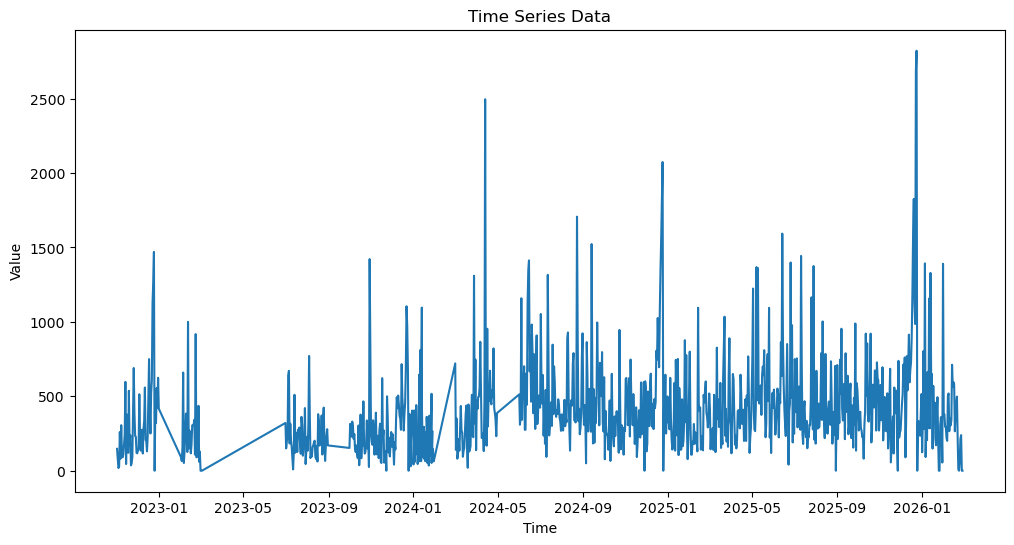

KS statistic for strict stationarity: 0.21694188376753507
KS p-value for strict stationarity: 9.79323741108493e-11


In [93]:
# Check if the data is strict stationary or not

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

def ks_test_stationarity(data):
   split = len(data) // 2
   first_half = data[:split]
   second_half = data[split:]
   statistic, p_value = ks_2samp(first_half, second_half)
   return statistic, p_value


# Perform the KS test for stationarity
ks_stat_strict, ks_pvalue_strict = ks_test_stationarity(df2['total'])

# Plotting the series
plt.figure(figsize=(12, 6))
plt.plot(df2['total'])
plt.title('Time Series Data')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()
print(f"KS statistic for strict stationarity: {ks_stat_strict}")
print(f"KS p-value for strict stationarity: {ks_pvalue_strict}")

In [94]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

In [95]:
df2['weekly_total_diff']= df2['total']-df2['total'].shift(7) # as we can check how did this week perform compared to previous week.


In [96]:
adf_test(df2['weekly_total_diff'], name="Weekly Differenced Sales Data")


ADF Test Results for Weekly Differenced Sales Data
----------------------------------------
ADF Statistic: -10.6080
p-value: 0.0000
Critical Values:
  1%: -3.4371
  5%: -2.8645
  10%: -2.5684
Result: Stationary (reject H₀ at α=0.05)


In [97]:
df2.columns

Index(['day', 'time', 'total', 'total_employees_hours', 'total_employees',
       'total_tips', 'month', 'week', 'year', 'quarter', 'is_weekend',
       'total:10_days_rolling', 'total:30_days_rolling',
       'total:50_days_rolling', 'is_future', 'is_closed', 'is_suspicious_zero',
       'store_open', 'weekly_total_diff'],
      dtype='object')

In [98]:
# Checking if the data contains missing dates or gaps in the sales data
full_range = pd.date_range(df2.index.min(), df2.index.max(), freq="D")
print("Missing dates:", len(full_range.difference(df2.index)))

Missing dates: 246


In [99]:
# checking the correlation between days, weekly, biweekly till monthly rolling totals
for lag in [1, 2, 3, 7, 14, 21, 30]:
    print(f"Lag {lag}: {df2['total'].autocorr(lag=lag):.3f}")

Lag 1: 0.343
Lag 2: 0.254
Lag 3: 0.205
Lag 7: 0.238
Lag 14: 0.155
Lag 21: 0.138
Lag 30: 0.015


<Axes: >

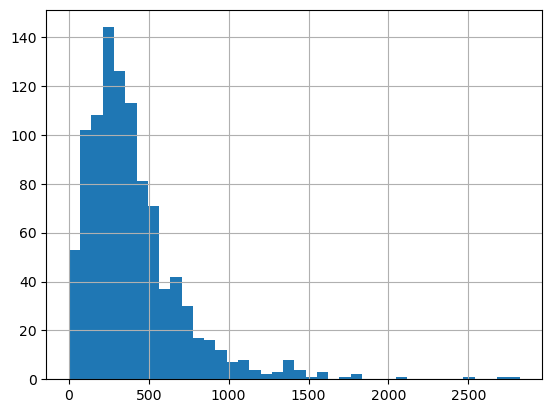

In [100]:
df2["total"].hist(bins=40)

We get to know that there is huge role in seasonality where during normal days the sales is between 200-500 and when there are holidays, events and unusual days the sales are higher. Thus using ARIMA or SARIMA wouldnt make sense as the as these models assume constant variance over time which is not the case in our data.

<Axes: xlabel='date'>

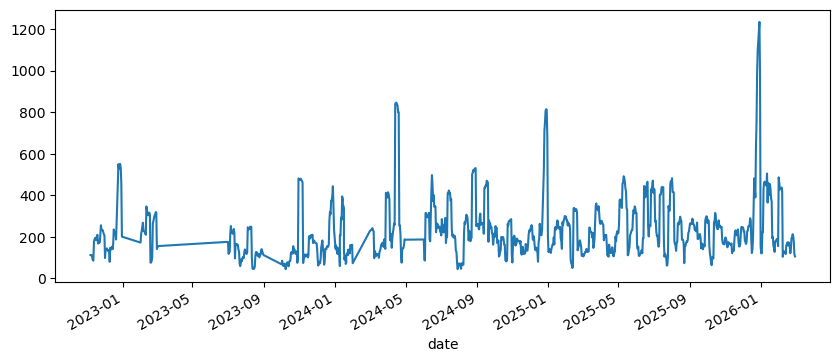

In [101]:
df2["total"].rolling(7).std().plot(figsize=(10,4))

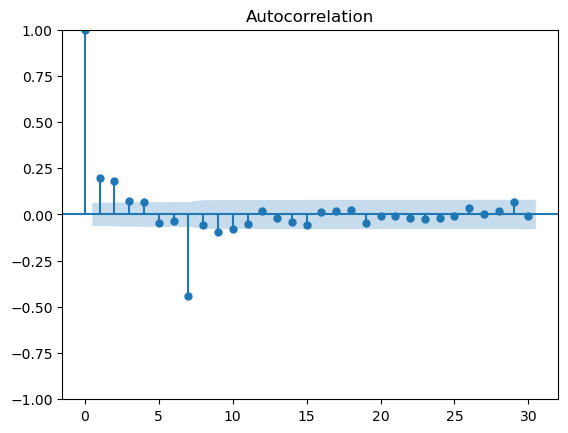

In [102]:
acf = plot_acf(df2['weekly_total_diff'].dropna())

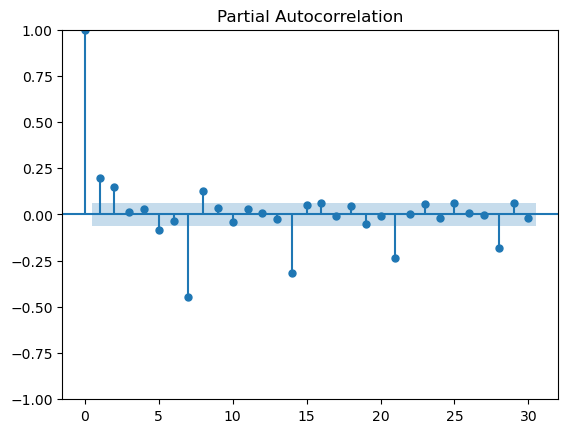

In [103]:
# Partial auto corrleation plot 
#With PACF we find out AR
#With ACF we find out MA
pacf = plot_pacf(df2['weekly_total_diff'].dropna())

## Seasonality Analysis and Anamoly Detection( Not Important in our case)

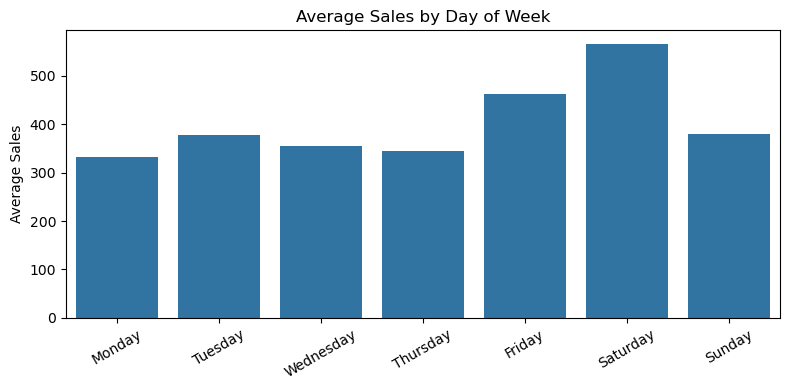

In [104]:
# Sales by Day of Week
df2['day_of_week'] = df2.index.day_name()

dow_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

avg_dow = (
    df2.groupby('day_of_week')['total']
       .mean()
       .reindex(dow_order)
)

plt.figure(figsize=(8,4))
sns.barplot(x=avg_dow.index, y=avg_dow.values)
plt.title('Average Sales by Day of Week')
plt.ylabel('Average Sales')
plt.xlabel('')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


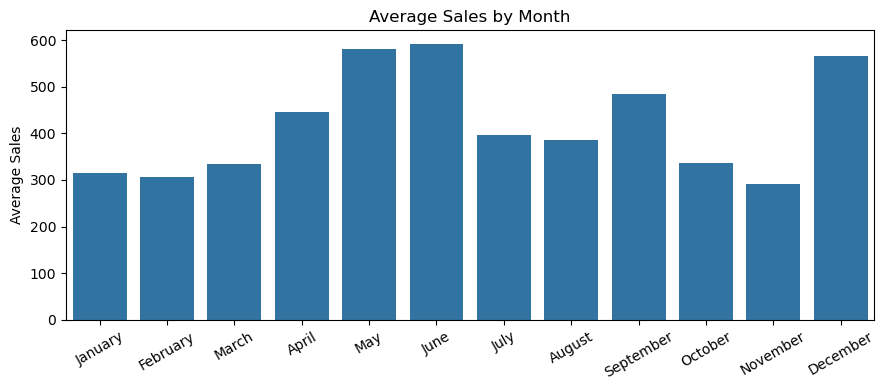

In [105]:
# Sale by Month
df2['month'] = df2.index.month
df2['month_name'] = df2.index.month_name()

month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

avg_month = (
    df2.groupby('month_name')['total']
       .mean()
       .reindex(month_order)
)

plt.figure(figsize=(9,4))
sns.barplot(x=avg_month.index, y=avg_month.values)
plt.title('Average Sales by Month')
plt.ylabel('Average Sales')
plt.xlabel('')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


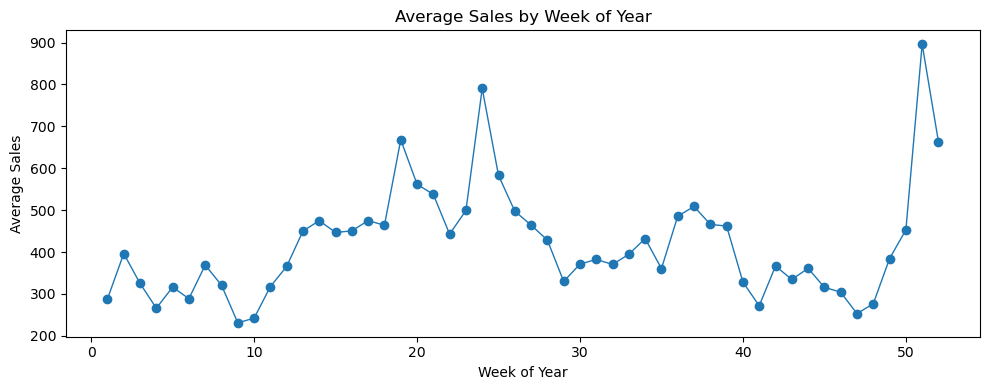

In [106]:
df2['week_of_year'] = df2.index.isocalendar().week

avg_week = (
    df2.groupby('week_of_year')['total']
       .mean()
)

plt.figure(figsize=(10,4))
plt.plot(avg_week.index, avg_week.values, marker='o', linewidth=1)
plt.title('Average Sales by Week of Year')
plt.ylabel('Average Sales')
plt.xlabel('Week of Year')
plt.tight_layout()
plt.show()


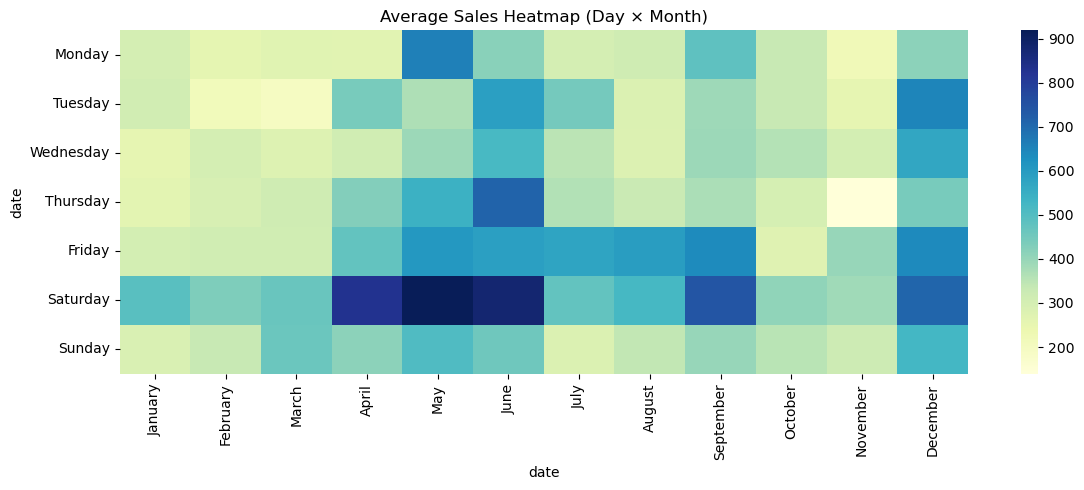

In [107]:
pivot = df2.pivot_table(
    values='total',
    index=df2.index.day_name(),
    columns=df2.index.month_name(),
    aggfunc='mean'
).reindex(index=dow_order, columns=month_order)

plt.figure(figsize=(12,5))
sns.heatmap(pivot, cmap='YlGnBu')
plt.title('Average Sales Heatmap (Day × Month)')
plt.tight_layout()
plt.show()


## Adding US Holidays

In [108]:
import holidays
us_holidays = holidays.US()

df2["is_holiday"] = df2.index.to_series().apply(lambda x: x in us_holidays).astype(int)

In [109]:
holiday_dates = pd.to_datetime(list(us_holidays.keys()))

df2["days_to_next_holiday"] = df2.index.to_series().apply(
    lambda x: min([(h - x).days for h in holiday_dates if (h - x).days >= 0] + [365])
)

In [110]:
df2[["days_to_next_holiday"]].head(10)

,days_to_next_holiday
date,
2022-11-01,10
2022-11-02,9
2022-11-03,8
2022-11-04,7
2022-11-05,6
2022-11-06,5
2022-11-07,4
2022-11-08,3
2022-11-09,2


In [111]:
df2[["total","is_holiday","days_to_next_holiday"]].tail(20)

,total,is_holiday,days_to_next_holiday
date,,,
2026-02-09,266.0,0,7
2026-02-10,353.0,0,6
2026-02-11,305.0,0,5
2026-02-12,339.0,0,4
2026-02-13,712.0,0,3
2026-02-14,565.0,0,2
2026-02-15,595.0,0,1
2026-02-16,581.0,1,0
2026-02-17,265.0,0,97


In [112]:
# Right now the feature has very large values (90–300 days) which don't add much signal. common trick is capping the feature.

df2["days_to_next_holiday"] = df2["days_to_next_holiday"].clip(upper=30)

In [113]:
df2.columns

Index(['day', 'time', 'total', 'total_employees_hours', 'total_employees',
       'total_tips', 'month', 'week', 'year', 'quarter', 'is_weekend',
       'total:10_days_rolling', 'total:30_days_rolling',
       'total:50_days_rolling', 'is_future', 'is_closed', 'is_suspicious_zero',
       'store_open', 'weekly_total_diff', 'day_of_week', 'month_name',
       'week_of_year', 'is_holiday', 'days_to_next_holiday'],
      dtype='object')

In [114]:
# Drop the columns that are not needed
df2.drop(["day","year", "time", "is_future", "total_employees_hours", "total_employees", "total_tips"], axis=1, inplace=True)

In [115]:
df2.columns


Index(['total', 'month', 'week', 'quarter', 'is_weekend',
       'total:10_days_rolling', 'total:30_days_rolling',
       'total:50_days_rolling', 'is_closed', 'is_suspicious_zero',
       'store_open', 'weekly_total_diff', 'day_of_week', 'month_name',
       'week_of_year', 'is_holiday', 'days_to_next_holiday'],
      dtype='object')

In [116]:
# Lag features which are important for time series
df2["lag_1"] = df2["total"].shift(1)
df2["lag_7"] = df2["total"].shift(7)
df2["lag_14"] = df2["total"].shift(14)

In [117]:
df2 = df2.dropna()

In [118]:
df2.corr(numeric_only=True)["total"].sort_values(ascending=False)

total                    1.000000
weekly_total_diff        0.621486
total:10_days_rolling    0.342025
lag_1                    0.336730
total:30_days_rolling    0.284709
total:50_days_rolling    0.250716
lag_7                    0.231533
store_open               0.168693
lag_14                   0.147301
week_of_year             0.146967
week                     0.146967
month                    0.143709
is_weekend               0.136319
quarter                  0.105288
is_holiday              -0.081918
days_to_next_holiday    -0.135066
is_closed               -0.168693
is_suspicious_zero            NaN
Name: total, dtype: float64

In [119]:
df2 = df2.rename(columns={
    "total:10_days_rolling": "total_10_days_rolling",
    "total:30_days_rolling": "total_30_days_rolling",
    "total:50_days_rolling": "total_50_days_rolling"
})

## Save the Processed Data

In [120]:
from pathlib import Path

# Save cleaned EDA dataframe for model training notebook
out_candidates = [Path('../datasets/eda_cleaned.csv'), Path('datasets/eda_cleaned.csv')]
out_path = next((p for p in out_candidates if p.parent.exists()), out_candidates[0])

df2_to_save = df2.copy().reset_index()
df2_to_save.to_csv(out_path, index=False)
print(f'Saved cleaned data: {out_path} | rows={len(df2_to_save)}, cols={len(df2_to_save.columns)}')


Saved cleaned data: ../datasets/eda_cleaned.csv | rows=949, cols=21


In [121]:
df2.index.max()

Timestamp('2026-02-28 00:00:00')

In [122]:
df2.columns

Index(['total', 'month', 'week', 'quarter', 'is_weekend',
       'total_10_days_rolling', 'total_30_days_rolling',
       'total_50_days_rolling', 'is_closed', 'is_suspicious_zero',
       'store_open', 'weekly_total_diff', 'day_of_week', 'month_name',
       'week_of_year', 'is_holiday', 'days_to_next_holiday', 'lag_1', 'lag_7',
       'lag_14'],
      dtype='object')